In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# styl wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# połączenie z bazą
conn = sqlite3.connect('running.db')

# główny dataframe
df = pd.read_sql_query("""
    SELECT 
        r.date, r.distance_km, r.duration_min, r.avg_speed,
        r.calories, r.avg_heart_rate, r.max_heart_rate,
        r.training_effect, r.vo2max, r.recovery_time_h,
        w.temperature, w.pressure, w.humidity,
        w.pressure - wp.pressure_prev as pressure_change,
        s.headache, s.energy_before, s.energy_after
    FROM runs r
    LEFT JOIN weather w ON w.date = r.date
    LEFT JOIN weather_prev wp ON wp.date = r.date
    LEFT JOIN wellbeing s ON s.run_id = r.id
    ORDER BY r.date ASC
""", conn)

df['date'] = pd.to_datetime(df['date'])
print(f"Dataset: {len(df)} runs")
print(df.dtypes)
df.head()

Dataset: 21 runs
date               datetime64[us]
distance_km               float64
duration_min                int64
avg_speed                 float64
calories                    int64
avg_heart_rate              int64
max_heart_rate              int64
training_effect           float64
vo2max                    float64
recovery_time_h             int64
temperature               float64
pressure                    int64
humidity                    int64
pressure_change             int64
headache                    int64
energy_before               int64
energy_after                int64
dtype: object


,date,distance_km,duration_min,avg_speed,calories,avg_heart_rate,max_heart_rate,training_effect,vo2max,recovery_time_h,temperature,pressure,humidity,pressure_change,headache,energy_before,energy_after
0,2026-04-13,5.0,40,7.4,414,161,188,4.7,46.0,64,13.9,1010,35,5,0,4,1
1,2026-04-15,5.0,37,8.1,320,151,180,3.4,46.0,24,15.6,1008,45,5,0,4,2
2,2026-04-20,5.0,38,7.8,316,146,162,2.9,45.0,21,13.9,1001,46,0,0,4,1
3,2026-04-22,5.0,35,8.5,327,157,170,3.2,45.0,24,16.3,1006,29,-1,0,4,2
4,2026-04-27,5.0,37,8.2,332,154,169,3.2,45.0,23,13.4,1008,23,0,0,3,1


In [4]:
# Note: with 21 records memory optimization has no practical impact,
# but demonstrates awareness of data types and efficient storage.

In [5]:
# optymalizacja typów
df['headache'] = df['headache'].astype('bool')
df['energy_before'] = df['energy_before'].astype('int8')   # wartości 1-5
df['energy_after'] = df['energy_after'].astype('int8')     # wartości 1-5
df['avg_heart_rate'] = df['avg_heart_rate'].astype('int16')
df['max_heart_rate'] = df['max_heart_rate'].astype('int16')
df['calories'] = df['calories'].astype('int16')
df['duration_min'] = df['duration_min'].astype('int16')
df['humidity'] = df['humidity'].astype('int8')             # 0-100%

print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

date               datetime64[us]
distance_km               float64
duration_min                int16
avg_speed                 float64
calories                    int16
avg_heart_rate              int16
max_heart_rate              int16
training_effect           float64
vo2max                    float64
recovery_time_h             int64
temperature               float64
pressure                    int64
humidity                     int8
pressure_change             int64
headache                     bool
energy_before                int8
energy_after                 int8
dtype: object

Memory usage: 1.85 KB


In [6]:
# podstawowe statystyki
df.describe().round(2)

,date,distance_km,duration_min,avg_speed,calories,avg_heart_rate,max_heart_rate,training_effect,vo2max,recovery_time_h,temperature,pressure,humidity,pressure_change,energy_before,energy_after
count,21,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
mean,2026-05-26 10:17:08.571428,5.09,35.10,8.70,332.86,159.19,176.62,3.52,43.61,28.81,19.54,1003.38,47.48,-0.76,4.24,2.14
min,2026-04-13 00:00:00,5.00,30.00,7.40,311.00,146.00,162.00,2.90,42.00,21.00,8.20,993.00,23.00,-12.00,3.00,1.00
25%,2026-04-29 00:00:00,5.00,34.00,8.30,320.00,154.00,169.00,3.30,43.00,24.00,16.30,1000.00,42.00,-3.00,4.00,1.00
50%,2026-05-31 00:00:00,5.00,35.00,8.60,327.00,158.00,177.00,3.40,43.00,25.00,20.80,1003.00,46.00,0.00,4.00,2.00
75%,2026-06-15 00:00:00,5.10,37.00,9.10,337.00,163.00,185.00,3.80,45.00,29.00,22.10,1006.00,56.00,1.00,5.00,3.00
max,2026-07-22 00:00:00,5.55,40.00,10.60,414.00,172.00,188.00,4.70,46.00,64.00,31.10,1015.00,75.00,7.00,5.00,4.00
std,NaN,0.16,2.21,0.66,22.09,6.79,8.93,0.40,1.29,9.62,5.10,5.70,13.37,4.84,0.62,0.96


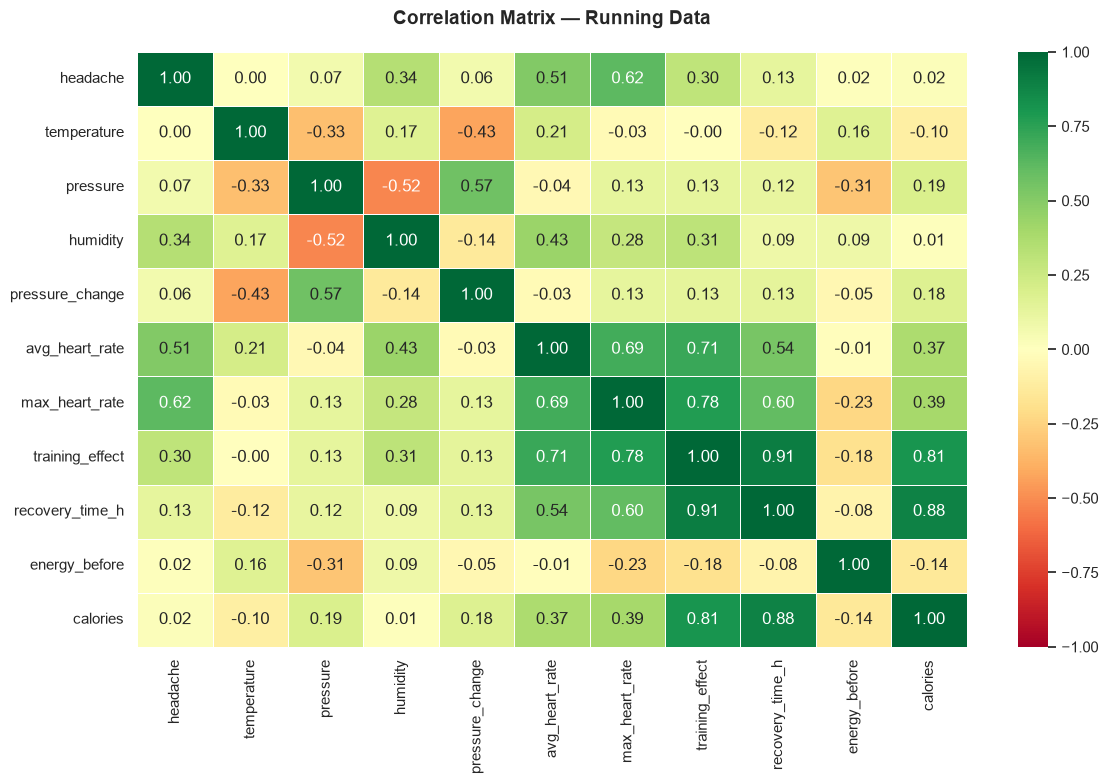


Correlations with headache (sorted):
max_heart_rate     0.619
avg_heart_rate     0.510
humidity           0.340
training_effect    0.300
recovery_time_h    0.131
pressure           0.070
pressure_change    0.064
calories           0.019
energy_before      0.015
temperature        0.001
Name: headache, dtype: float64


In [7]:
# wybierz zmienne numeryczne
corr_cols = [
    'headache', 'temperature', 'pressure', 'humidity', 'pressure_change',
    'avg_heart_rate', 'max_heart_rate', 'training_effect',
    'recovery_time_h', 'energy_before', 'calories'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Correlation Matrix — Running Data', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('docs/screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# pokaż korelacje z bólem głowy posortowane
print("\nCorrelations with headache (sorted):")
print(corr_matrix['headache'].drop('headache').sort_values(key=abs, ascending=False).round(3))

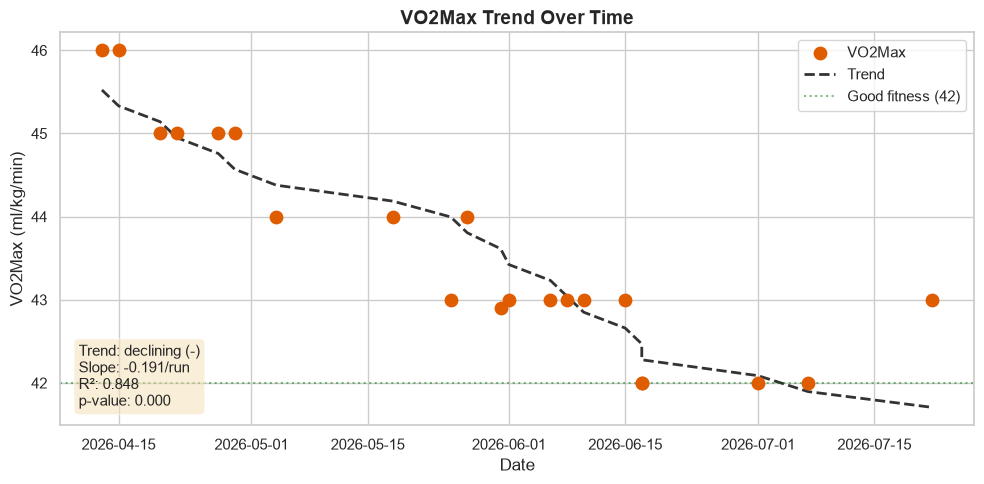


Slope: -0.1909 per run
R²: 0.8482
p-value: 0.0000 (statistically significant)


In [8]:
# przygotuj dane
df_vo2 = df.dropna(subset=['vo2max']).copy()
df_vo2['run_number'] = range(1, len(df_vo2) + 1)

# regresja liniowa
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_vo2['run_number'], df_vo2['vo2max']
)

fig, ax = plt.subplots(figsize=(10, 5))

# punkty
ax.scatter(df_vo2['date'], df_vo2['vo2max'], 
           color='#e05c00', s=80, zorder=5, label='VO2Max')

# linia trendu
trend_y = slope * df_vo2['run_number'] + intercept
ax.plot(df_vo2['date'], trend_y, 
        color='#333', linestyle='--', linewidth=2, label='Trend')

# strefa referencyjna
ax.axhline(y=42, color='green', linestyle=':', alpha=0.5, label='Good fitness (42)')

ax.set_title('VO2Max Trend Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VO2Max (ml/kg/min)')
ax.legend()

# adnotacja z wynikiem
direction = "improving (+)" if slope > 0 else "declining (-)"
ax.annotate(
    f'Trend: {direction}\nSlope: {slope:.3f}/run\nR²: {r_value**2:.3f}\np-value: {p_value:.3f}',
    xy=(0.02, 0.05), xycoords='axes fraction',
    fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.savefig('docs/screenshots/vo2max_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSlope: {slope:.4f} per run")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f} {'(statistically significant)' if p_value < 0.05 else '(not yet significant — need more data)'}")

In [9]:
# Note: The declining trend may reflect sensor calibration rather than 
# actual fitness decline. Huawei watches tend to overestimate VO2Max 
# in early sessions before the algorithm learns the user's physiology.
# The stabilization around 42-43 ml/kg/min after ~10 runs suggests 
# this is the actual baseline. Further monitoring needed.

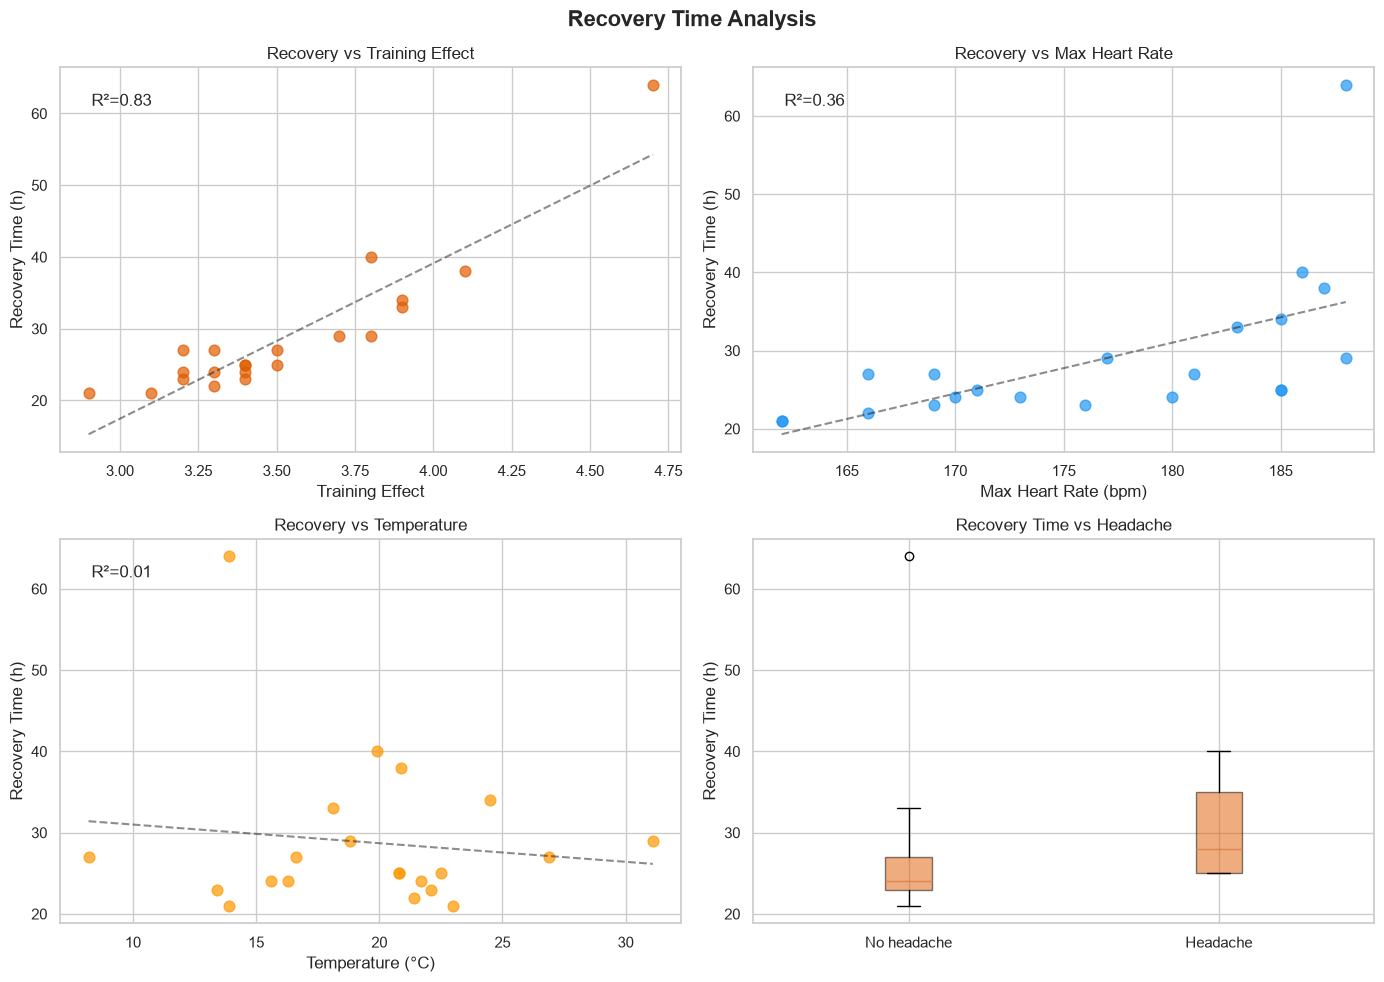


Avg recovery — no headache: 27.8h
Avg recovery — headache: 30.4h


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Recovery Time Analysis', fontsize=16, fontweight='bold')

# 1. Recovery vs Training Effect
axes[0,0].scatter(df['training_effect'], df['recovery_time_h'], 
                  color='#e05c00', s=60, alpha=0.7)
axes[0,0].set_xlabel('Training Effect')
axes[0,0].set_ylabel('Recovery Time (h)')
axes[0,0].set_title('Recovery vs Training Effect')

slope1, intercept1, r1, _, _ = stats.linregress(
    df.dropna(subset=['training_effect','recovery_time_h'])['training_effect'],
    df.dropna(subset=['training_effect','recovery_time_h'])['recovery_time_h']
)
x_range = pd.Series([df['training_effect'].min(), df['training_effect'].max()])
axes[0,0].plot(x_range, slope1 * x_range + intercept1, 'k--', alpha=0.5)
axes[0,0].annotate(f'R²={r1**2:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')

# 2. Recovery vs Max HR
axes[0,1].scatter(df['max_heart_rate'], df['recovery_time_h'],
                  color='#2196F3', s=60, alpha=0.7)
axes[0,1].set_xlabel('Max Heart Rate (bpm)')
axes[0,1].set_ylabel('Recovery Time (h)')
axes[0,1].set_title('Recovery vs Max Heart Rate')

slope2, intercept2, r2, _, _ = stats.linregress(
    df.dropna(subset=['max_heart_rate','recovery_time_h'])['max_heart_rate'],
    df.dropna(subset=['max_heart_rate','recovery_time_h'])['recovery_time_h']
)
x_range2 = pd.Series([df['max_heart_rate'].min(), df['max_heart_rate'].max()])
axes[0,1].plot(x_range2, slope2 * x_range2 + intercept2, 'k--', alpha=0.5)
axes[0,1].annotate(f'R²={r2**2:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')

# 3. Recovery vs Temperature
axes[1,0].scatter(df['temperature'], df['recovery_time_h'],
                  color='#ff9800', s=60, alpha=0.7)
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Recovery Time (h)')
axes[1,0].set_title('Recovery vs Temperature')

slope3, intercept3, r3, _, _ = stats.linregress(
    df.dropna(subset=['temperature','recovery_time_h'])['temperature'],
    df.dropna(subset=['temperature','recovery_time_h'])['recovery_time_h']
)
x_range3 = pd.Series([df['temperature'].min(), df['temperature'].max()])
axes[1,0].plot(x_range3, slope3 * x_range3 + intercept3, 'k--', alpha=0.5)
axes[1,0].annotate(f'R²={r3**2:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')

# 4. Recovery — headache vs no headache
recovery_no = df[df['headache']==0]['recovery_time_h'].dropna()
recovery_yes = df[df['headache']==1]['recovery_time_h'].dropna()

axes[1,1].boxplot([recovery_no, recovery_yes], 
                   tick_labels=['No headache', 'Headache'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#e05c00', alpha=0.5))
axes[1,1].set_ylabel('Recovery Time (h)')
axes[1,1].set_title('Recovery Time vs Headache')

plt.tight_layout()
plt.savefig('docs/screenshots/recovery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg recovery — no headache: {recovery_no.mean():.1f}h")
print(f"Avg recovery — headache: {recovery_yes.mean():.1f}h")

In [11]:
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)

# 1. Headache
headache_corr = df[corr_cols].corr()['headache'].drop('headache')
top_factor = headache_corr.abs().idxmax()
print(f"\n1. HEADACHE ANALYSIS")
print(f"   Strongest correlate: {top_factor} ({headache_corr[top_factor]:.3f})")
print(f"   Runs with headache: {int(df['headache'].sum())} / {len(df)}")
print("""   - Max heart rate is the strongest predictor (r=0.62)
   - Weather conditions (temperature, pressure) have minimal impact
   - Conclusion: headaches are effort-driven, not weather-driven""")

# 2. VO2Max
print(f"\n2. VO2MAX TREND")
print(f"   First run: {df_vo2['vo2max'].iloc[0]}")
print(f"   Latest run: {df_vo2['vo2max'].iloc[-1]}")
print(f"   Change: {df_vo2['vo2max'].iloc[-1] - df_vo2['vo2max'].iloc[0]:+.1f}")
print(f"   Trend: {direction}")
print("""   - Declining trend likely reflects sensor calibration
   - Stabilized around 42-43 ml/kg/min after ~10 runs
   - Recommend re-evaluating after 50+ runs""")

# 3. Recovery
print(f"\n3. RECOVERY TIME")
print(f"   Strongest predictor: Training Effect (R²={r1**2:.2f})")
print(f"   Avg recovery: {df['recovery_time_h'].mean():.1f}h")
print("""   - Training Effect is the best predictor (R²=0.83)
   - Headache sessions require ~2.6h more recovery
   - Temperature has no meaningful impact (R²=0.01)""")

print(f"\n⚠️  Note: Dataset is small ({len(df)} runs). Conclusions are preliminary.")

KEY FINDINGS

1. HEADACHE ANALYSIS
   Strongest correlate: max_heart_rate (0.619)
   Runs with headache: 8 / 21
   - Max heart rate is the strongest predictor (r=0.62)
   - Weather conditions (temperature, pressure) have minimal impact
   - Conclusion: headaches are effort-driven, not weather-driven

2. VO2MAX TREND
   First run: 46.0
   Latest run: 43.0
   Change: -3.0
   Trend: declining (-)
   - Declining trend likely reflects sensor calibration
   - Stabilized around 42-43 ml/kg/min after ~10 runs
   - Recommend re-evaluating after 50+ runs

3. RECOVERY TIME
   Strongest predictor: Training Effect (R²=0.83)
   Avg recovery: 28.8h
   - Training Effect is the best predictor (R²=0.83)
   - Headache sessions require ~2.6h more recovery
   - Temperature has no meaningful impact (R²=0.01)

⚠️  Note: Dataset is small (21 runs). Conclusions are preliminary.
